In [1]:
from datasets import load_dataset

meta = load_dataset(
    "th1nhng0/vietnamese-legal-documents",
    "metadata",
    split="data"
)

c:\Users\LAPTOP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
meta[0]

{'id': 72,
 'title': 'Sắc lệnh quy định liên hệ giữa UBKCHC và các cơ quan chuyên môn',
 'so_ky_hieu': '103/SL',
 'ngay_ban_hanh': '05/06/1950',
 'loai_van_ban': 'Sắc lệnh',
 'ngay_co_hieu_luc': '20/06/1950',
 'ngay_het_hieu_luc': None,
 'nguon_thu_thap': 'Công báo số 7/1950;',
 'ngay_dang_cong_bao': '...',
 'nganh': None,
 'linh_vuc': None,
 'co_quan_ban_hanh': 'Chủ tịch nước',
 'chuc_danh': 'Chủ tịch nước',
 'nguoi_ky': 'Hồ Chí Minh',
 'pham_vi': None,
 'thong_tin_ap_dung': None,
 'tinh_trang_hieu_luc': 'Hết hiệu lực toàn bộ'}

In [3]:
import pandas as pd

path = r"C:\Users\LAPTOP\.cache\huggingface\hub\datasets--th1nhng0--vietnamese-legal-documents\snapshots\0a39ad7eae8e6c188cb225c4b1443c3b346461d8\data\content.parquet"

content = pd.read_parquet(path)



In [4]:
content.iloc[0]

id                                                           4260
content_html    <table class="detailcontent" width="100%" bord...
Name: 0, dtype: str

In [5]:
rels = load_dataset(
    "th1nhng0/vietnamese-legal-documents",
    "relationships",
    split="data"
)

In [6]:
rels[0]

{'doc_id': 4260, 'other_doc_id': '10420', 'relationship': 'Văn bản căn cứ'}

In [7]:
import pandas as pd

df = meta.to_pandas()

rel = rels.to_pandas()

citing = (
    rel[
        rel["other_doc_id"]=="10420"
    ]
    .merge(
        df,
        left_on="doc_id",
        right_on="id"
    )
)

print(
    citing[
        [
            "id",
            "title",
            "relationship"
        ]
    ]
)

          id                                              title  \
0       4260  Về việc chuyển giao nhiệm vụ quản lý Nhà nước ...   
1       4263  Về việc xử lý đối với quỹ nhà thuộc quyền sở h...   
2       4271  Về việc cho phép thành lập Quỹ bảo trợ nạn nhâ...   
3       4293  Về việc thành lập Chi cục phát triển Lâm nghiệ...   
4       4204  Ban hành quy định phân cấp quản lý công tác Tổ...   
...      ...                                                ...   
6144  136428  Nghị quyết về việc thông qua phương án, tờ trì...   
6145  136504  Nghị quyết về việc thông qua danh mục sửa đổi,...   
6146  138672  Về bãi bỏ các văn bản của UBND tỉnh về việc qu...   
6147  105678  Về dự toán thu ngân sách Nhà nước trên địa bàn...   
6148   57720  V/v Ban hành qui định tạm thòi về một số nhiệm...   

        relationship  
0     Văn bản căn cứ  
1     Văn bản căn cứ  
2     Văn bản căn cứ  
3     Văn bản căn cứ  
4     Văn bản căn cứ  
...              ...  
6144  Văn bản căn cứ  
6145  Văn b

In [8]:
meta_df = meta.to_pandas()     
content_df = content          

In [9]:
content_df["id"] = pd.to_numeric(
    content_df["id"],
    errors="coerce"
)

content_df = content_df.dropna(subset=["id"])
content_df["id"] = content_df["id"].astype(int)

docs = meta_df.merge(content_df, on="id", how="inner")

In [10]:
meta_df = meta.to_pandas()

content_df["id"] = content_df["id"].astype(int)

docs = meta_df.merge(
    content_df,
    on="id",
    how="inner"
)

print(docs.shape)
docs.head()

(176193, 18)


,id,title,so_ky_hieu,ngay_ban_hanh,loai_van_ban,ngay_co_hieu_luc,ngay_het_hieu_luc,nguon_thu_thap,ngay_dang_cong_bao,nganh,linh_vuc,co_quan_ban_hanh,chuc_danh,nguoi_ky,pham_vi,thong_tin_ap_dung,tinh_trang_hieu_luc,content_html
0,72,Sắc lệnh quy định liên hệ giữa UBKCHC và các c...,103/SL,05/06/1950,Sắc lệnh,20/06/1950,NaN,Công báo số 7/1950;,...,NaN,NaN,Chủ tịch nước,Chủ tịch nước,Hồ Chí Minh,NaN,NaN,Hết hiệu lực toàn bộ,"<table class=""detailcontent"" width=""100%"" bord..."
1,72,Sắc lệnh quy định liên hệ giữa UBKCHC và các c...,103/SL,05/06/1950,Sắc lệnh,20/06/1950,NaN,Công báo số 7/1950;,...,NaN,NaN,Chủ tịch nước,Chủ tịch nước,Hồ Chí Minh,NaN,NaN,Hết hiệu lực toàn bộ,"<table class=""detailcontent"" width=""100%"" bord..."
2,4260,Về việc chuyển giao nhiệm vụ quản lý Nhà nước ...,87/1999/QĐ-UB,12/07/1999,Quyết định,12/07/1999,NaN,STP tỉnh Lâm Đồng;,...,NaN,NaN,UBND tỉnh Lâm Đồng,Q.Chủ tịch,Đặng Đức Lợi,Lâm Đồng,NaN,Còn hiệu lực,"<table class=""detailcontent"" width=""100%"" bord..."
3,4260,Về việc chuyển giao nhiệm vụ quản lý Nhà nước ...,87/1999/QĐ-UB,12/07/1999,Quyết định,12/07/1999,NaN,STP tỉnh Lâm Đồng;,...,NaN,NaN,UBND tỉnh Lâm Đồng,Q.Chủ tịch,Đặng Đức Lợi,Lâm Đồng,NaN,Còn hiệu lực,"<table class=""detailcontent"" width=""100%"" bord..."
4,4280,Về viẹc quản lý và quy định thống nhất phí chợ...,157/1999/QĐ-UB,19/11/1999,Quyết định,19/11/1999,NaN,STP tỉnh Lâm Đồng;,...,Tài chính,NaN,UBND tỉnh Lâm Đồng,Phó Chủ tịch,Trương Thành Trung,Lâm Đồng,NaN,Còn hiệu lực,"<table class=""detailcontent"" width=""100%"" bord..."


In [11]:
print(f"Số văn bản: {len(docs):,}")
print(f"Số cột: {docs.shape[1]}")

Số văn bản: 176,193
Số cột: 18


In [12]:
missing = (
    docs.isnull()
        .sum()
        .sort_values(ascending=False)
)

print(missing)

thong_tin_ap_dung      176193
ngay_het_hieu_luc      131107
linh_vuc               127293
nganh                   68629
nguon_thu_thap          65908
pham_vi                 14537
nguoi_ky                  881
chuc_danh                 707
co_quan_ban_hanh          503
loai_van_ban                6
title                       0
id                          0
ngay_ban_hanh               0
ngay_co_hieu_luc            0
ngay_dang_cong_bao          0
so_ky_hieu                  0
tinh_trang_hieu_luc         0
content_html                0
dtype: int64


In [13]:
missing_percent = (
    docs.isnull().mean()*100
).sort_values(ascending=False)

print(missing_percent)

thong_tin_ap_dung      100.000000
ngay_het_hieu_luc       74.411015
linh_vuc                72.246343
nganh                   38.951037
nguon_thu_thap          37.406707
pham_vi                  8.250612
nguoi_ky                 0.500020
chuc_danh                0.401265
co_quan_ban_hanh         0.285482
loai_van_ban             0.003405
title                    0.000000
id                       0.000000
ngay_ban_hanh            0.000000
ngay_co_hieu_luc         0.000000
ngay_dang_cong_bao       0.000000
so_ky_hieu               0.000000
tinh_trang_hieu_luc      0.000000
content_html             0.000000
dtype: float64


In [14]:
docs.info()

<class 'pandas.DataFrame'>
RangeIndex: 176193 entries, 0 to 176192
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   id                   176193 non-null  int64
 1   title                176193 non-null  str  
 2   so_ky_hieu           176193 non-null  str  
 3   ngay_ban_hanh        176193 non-null  str  
 4   loai_van_ban         176187 non-null  str  
 5   ngay_co_hieu_luc     176193 non-null  str  
 6   ngay_het_hieu_luc    45086 non-null   str  
 7   nguon_thu_thap       110285 non-null  str  
 8   ngay_dang_cong_bao   176193 non-null  str  
 9   nganh                107564 non-null  str  
 10  linh_vuc             48900 non-null   str  
 11  co_quan_ban_hanh     175690 non-null  str  
 12  chuc_danh            175486 non-null  str  
 13  nguoi_ky             175312 non-null  str  
 14  pham_vi              161656 non-null  str  
 15  thong_tin_ap_dung    0 non-null       str  
 16  tinh_trang_hi

In [15]:
docs["loai_van_ban"].value_counts().head(20)

loai_van_ban
Quyết định              99362
Nghị quyết              27117
Thông tư                21896
Chỉ thị                 10194
Nghị định                8370
Thông tư liên tịch       4307
Sắc lệnh                 1956
Luật                      959
Lệnh                      696
Pháp lệnh                 466
Nghị Quyết                437
Văn bản liên quan          86
Chương trình               60
Văn bản hợp nhất           50
Nghị quyết liên tịch       48
Hiệp định                  46
Công văn                   43
Bộ luật                    29
Văn bản khác               16
Hiến pháp                  13
Name: count, dtype: int64

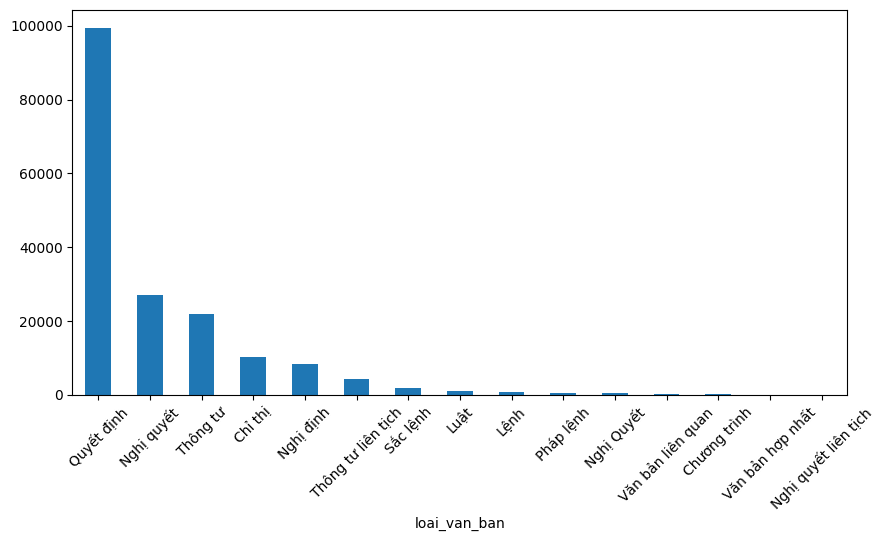

In [16]:
import matplotlib.pyplot as plt

docs["loai_van_ban"].value_counts().head(15).plot.bar(figsize=(10,5))

plt.xticks(rotation=45)
plt.show()

In [17]:
docs["co_quan_ban_hanh"].value_counts().head(20)

co_quan_ban_hanh
Bộ Tài chính                              10328
Thủ tướng Chính phủ                        8963
Chính phủ                                  7851
UBND thành phố Hồ Chí Minh                 4751
Ủy ban nhân dân tỉnh Lào Cai               3729
Bộ Nông nghiệp và Phát triển nông thôn     3152
UBND thành phố Hà Nội                      2749
UBND tỉnh Nghệ An                          2409
UBND thành phố Hải Phòng                   2268
Bộ Giao thông vận tải                      2198
Bộ Y tế                                    2171
UBND thành phố Đà Nẵng                     2081
Ủy ban nhân dân tỉnh Bình Phước            2075
Bộ Lao động - Thương binh và Xã hội        1947
UBND tỉnh Bà Rịa - Vũng Tàu                1911
Quốc hội                                   1900
Ngân hàng Nhà nước                         1837
Hội đồng Bộ trưởng                         1822
UBND tỉnh Thừa Thiên Huế                   1787
Ủy ban nhân dân tỉnh Gia Lai               1747
Name: count, dtype: int

In [18]:
docs["tinh_trang_hieu_luc"].value_counts()

tinh_trang_hieu_luc
Hết hiệu lực toàn bộ       92295
Còn hiệu lực               75121
Hết hiệu lực một phần       5968
                            1661
Ngưng hiệu lực               686
Không còn phù hợp            350
Chưa có hiệu lực              82
Chưa xác định                 26
Ngưng hiệu lực một phần        4
Name: count, dtype: int64

In [20]:
docs["ngay_ban_hanh"] = pd.to_datetime(
    docs["ngay_ban_hanh"],
    dayfirst=True,
    errors="coerce"
)

docs["year"] = docs["ngay_ban_hanh"].dt.year

docs["year"].value_counts().sort_index()

year
1925.0       1
1945.0     176
1946.0     482
1947.0     218
1948.0     255
          ... 
2024.0    7152
2025.0    9423
2026.0     849
2055.0       1
3024.0       1
Name: count, Length: 85, dtype: int64

<Axes: xlabel='year'>

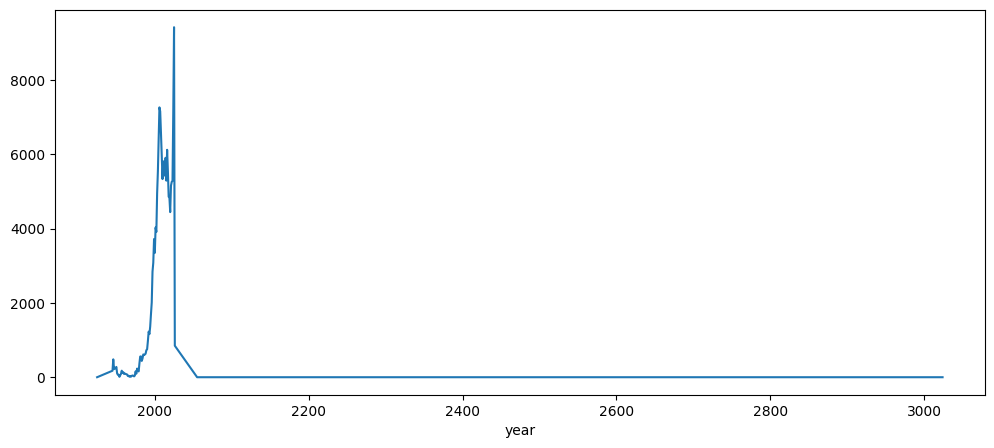

In [21]:
docs["year"].value_counts().sort_index().plot(figsize=(12,5))

In [22]:
docs["html_length"] = docs["content_html"].str.len()

docs["html_length"].describe()

count    1.761930e+05
mean     1.879132e+04
std      7.891324e+04
min      3.090000e+02
25%      2.973000e+03
50%      6.430000e+03
75%      1.667700e+04
max      1.168385e+07
Name: html_length, dtype: float64

In [36]:
docs["text_length"] = docs["text"].str.len()

docs["text_length"].describe()

count    1.468570e+05
mean     9.667970e+03
std      1.952244e+04
min      0.000000e+00
25%      1.684000e+03
50%      4.010000e+03
75%      1.097200e+04
max      1.270059e+06
Name: text_length, dtype: float64

In [ ]:
docs["num_words"] = docs["text"].str.split().str.len()

docs["num_words"].describe()

In [ ]:
docs.nlargest(10,"num_words")[
    [
        "id",
        "title",
        "num_words"
    ]
]

KeyError: 'num_words'

In [ ]:
rels["relationship"].value_counts()

AttributeError: 'Column' object has no attribute 'value_counts'

Kiểm tra số lượng bản ghi trùng

In [23]:
print(f"Số dòng: {len(docs):,}")

dup_id = docs["id"].duplicated().sum()
print(f"Số ID bị trùng: {dup_id}")

Số dòng: 176,193
Số ID bị trùng: 29336


In [24]:
duplicate_ids = docs["id"].value_counts()
duplicate_ids = duplicate_ids[duplicate_ids > 1]

print(duplicate_ids.head(20))

id
72      2
4260    2
4280    2
4263    2
77      2
75      2
58      2
95      2
4271    2
71      2
4204    2
4258    2
59      2
4274    2
78      2
60      2
56      2
57      2
4273    2
4265    2
Name: count, dtype: int64


In [25]:
sample_id = duplicate_ids.index[0]

docs[
    docs["id"] == sample_id
]

,id,title,so_ky_hieu,ngay_ban_hanh,loai_van_ban,ngay_co_hieu_luc,ngay_het_hieu_luc,nguon_thu_thap,ngay_dang_cong_bao,nganh,linh_vuc,co_quan_ban_hanh,chuc_danh,nguoi_ky,pham_vi,thong_tin_ap_dung,tinh_trang_hieu_luc,content_html,year,html_length
0,72,Sắc lệnh quy định liên hệ giữa UBKCHC và các c...,103/SL,1950-06-05,Sắc lệnh,20/06/1950,NaN,Công báo số 7/1950;,...,NaN,NaN,Chủ tịch nước,Chủ tịch nước,Hồ Chí Minh,NaN,NaN,Hết hiệu lực toàn bộ,"<table class=""detailcontent"" width=""100%"" bord...",1950.0,2600
1,72,Sắc lệnh quy định liên hệ giữa UBKCHC và các c...,103/SL,1950-06-05,Sắc lệnh,20/06/1950,NaN,Công báo số 7/1950;,...,NaN,NaN,Chủ tịch nước,Chủ tịch nước,Hồ Chí Minh,NaN,NaN,Hết hiệu lực toàn bộ,"<table class=""detailcontent"" width=""100%"" bord...",1950.0,2600


In [26]:
tmp = docs[docs["id"] == sample_id]

print(tmp["content_html"].duplicated())

0    False
1     True
Name: content_html, dtype: bool


In [27]:
cols = [
    "title",
    "so_ky_hieu",
    "ngay_ban_hanh",
    "co_quan_ban_hanh"
]

print(tmp[cols])

                                               title so_ky_hieu ngay_ban_hanh  \
0  Sắc lệnh quy định liên hệ giữa UBKCHC và các c...     103/SL    1950-06-05   
1  Sắc lệnh quy định liên hệ giữa UBKCHC và các c...     103/SL    1950-06-05   

  co_quan_ban_hanh  
0    Chủ tịch nước  
1    Chủ tịch nước  


In [28]:
docs = docs.drop_duplicates(
    subset=["id", "content_html"]
)

In [29]:
docs = docs.drop_duplicates(
    subset=["id"]
)

In [30]:
print(
    docs["id"].duplicated().sum()
)

0


In [31]:
from bs4 import BeautifulSoup

docs["text"] = docs["content_html"].apply(
    lambda html:
        BeautifulSoup(
            html,
            "html.parser"
        ).get_text(
            " ",
            strip=True
        )
)

In [45]:
docs = docs[
    docs["text"].str.len() > 30
]

In [ ]:
docs["num_chars"] = docs["text"].str.len()

docs["num_words"] = docs["text"].str.split().str.len()

In [ ]:
docs.describe()

Lưu các phiên bản

Raw Merge

In [32]:
docs_raw = docs.copy()

docs_raw.to_parquet(
    "legal_raw.parquet",
    index=False
)

In [33]:
docs.to_parquet(
    "legal_clean.parquet",
    index=False
)

In [34]:
docs.to_parquet(
    "legal_text.parquet",
    index=False
)

In [ ]:
docs.to_csv(
    "docs_with_text.csv",
    index=False,
    encoding="utf-8-sig"
)

In [35]:
rels_df = rels.to_pandas()

# Chuyển kiểu dữ liệu
rels_df["doc_id"] = rels_df["doc_id"].astype(int)
rels_df["other_doc_id"] = rels_df["other_doc_id"].astype(int)

# Loại bỏ cạnh trùng hoàn toàn
rels_df = rels_df.drop_duplicates(
    subset=["doc_id", "other_doc_id", "relationship"]
)

rels_df.to_parquet(
    "legal_relationships.parquet",
    index=False
)